# Практика: DBSCAN — плотностная кластеризация

## Что вы сделаете
В этом ноутбуке вы:

1. исследуете нелинейные 2D-датасеты и убедитесь в ограничениях K-Means;
2. построите **k-distance plot** и выберете оптимальный параметр `eps`;
3. применените **DBSCAN** и проанализируете результаты;
4. сравните DBSCAN с K-Means на нелинейных данных;
5. исследуете влияние гиперпараметров `eps` и `min_samples`;
6. применените DBSCAN к реальному датасету **Wine** и проанализируете шумовые точки;
7. сравните силуэт DBSCAN и K-Means, сделаете выводы.

## Важно
- Заполняйте все ячейки с пометкой `# YOUR CODE HERE`.
- Не удаляйте проверки: они подскажут, правильно ли вы идёте.
- Вопросы для размышления помогут вам глубже понять алгоритм.

## Датасеты
- **`make_moons`** и **`make_circles`** из `sklearn.datasets`: 2D-данные с нелинейными кластерами.
- **Wine** (`load_wine`): реальный многомерный датасет (13 признаков, 3 класса).

## Что сдавать
1. Заполненный ноутбук со всеми графиками.
2. Краткие выводы в конце каждого раздела.
3. Итоговый вывод: когда DBSCAN лучше K-Means и когда нет.

## Краткая теория

### Типы точек в DBSCAN

DBSCAN задаётся двумя параметрами: радиусом окрестности `eps` (ε) и минимальным числом точек `min_samples`.

- **Корневая точка** (core): в её ε-окрестности ≥ `min_samples` точек.
- **Граничная точка** (border): в её ε-окрестности < `min_samples`, но она достижима из корневой.
- **Шумовая точка** (noise): не является ни корневой, ни граничной → метка **-1**.

### Как работает алгоритм

1. Для каждой непосещённой точки найти её ε-окрестность.
2. Если точек ≥ `min_samples` — начать новый кластер.
3. Рекурсивно расширить кластер через цепочки плотно достижимых точек.
4. Оставшиеся точки → шум (метка -1).

### Как выбрать eps: k-distance plot

Для каждой точки вычисляют расстояние до её k-го ближайшего соседа (k = `min_samples`). Отсортированный по убыванию график этих расстояний называется **k-distance plot**. Резкий перегиб («локоть») указывает на оптимальное значение `eps`.

---
## Шаг 1. Импорты и настройки

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import make_moons, make_circles, load_wine
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Импорты выполнены успешно!")

Импорты выполнены успешно!


---
## Шаг 2. Исследование нелинейных датасетов

Сгенерируем два датасета, с которыми K-Means заведомо не справится.

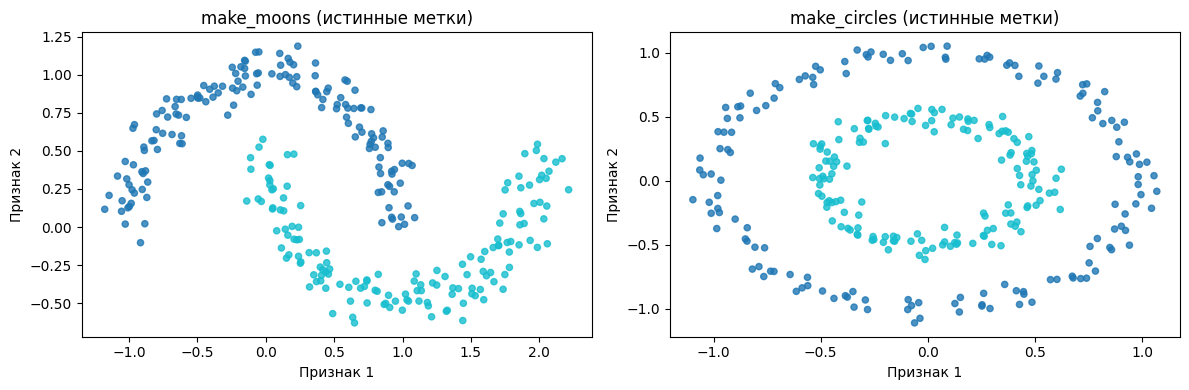

In [2]:
# Генерация датасетов
X_moons, y_moons = make_moons(n_samples=300, noise=0.08, random_state=RANDOM_STATE)
X_circles, y_circles = make_circles(n_samples=300, noise=0.05,
                                     factor=0.5, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=y_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("make_moons (истинные метки)")
axes[0].set_xlabel("Признак 1")
axes[0].set_ylabel("Признак 2")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=y_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("make_circles (истинные метки)")
axes[1].set_xlabel("Признак 1")
axes[1].set_ylabel("Признак 2")

plt.tight_layout()
plt.show()

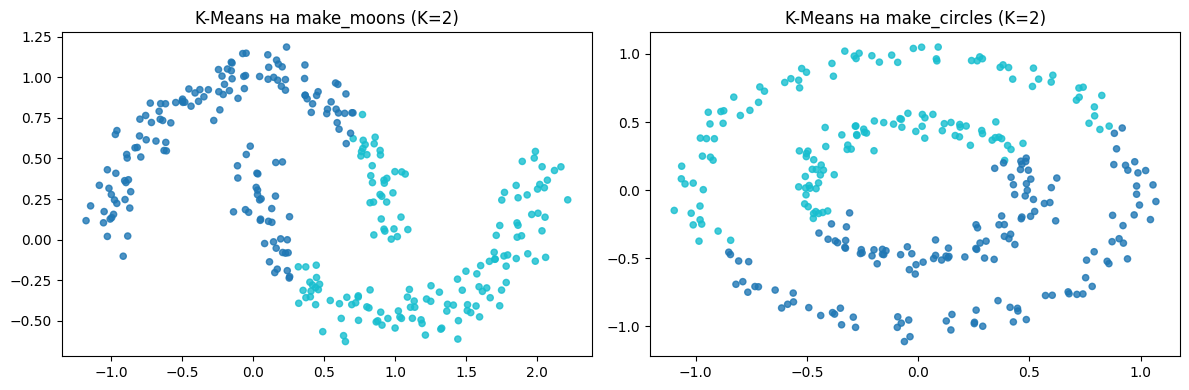

In [3]:
# Применим K-Means к этим датасетам
# YOUR CODE HERE
# 1. Создайте KMeans с n_clusters=2, random_state=RANDOM_STATE
# 2. Обучите на X_moons и X_circles
# 3. Получите метки кластеров

kmeans_moons = KMeans(n_clusters=2, random_state=RANDOM_STATE)
labels_km_moons = kmeans_moons.fit_predict(X_moons)

kmeans_circles = KMeans(n_clusters=2, random_state=RANDOM_STATE)
labels_km_circles = kmeans_circles.fit_predict(X_circles)

# Визуализация результатов K-Means
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=labels_km_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("K-Means на make_moons (K=2)")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=labels_km_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("K-Means на make_circles (K=2)")

plt.tight_layout()
plt.show()

**❓ Вопрос для размышления:** Почему K-Means не может правильно разделить «луны» и «кольца»? Связано ли это с формой функционала ошибки?

- Потому что KMeans строит центроиды, которые выпуклые, хорошо описываются одним центром. Луны вогнутые, как мы видим, а окружность концетрированные. Поэтому так плохо справился метод.

---
## Шаг 3. k-Distance Plot и выбор eps

Построим k-distance plot для датасета `make_moons`. Используем k = 5 (= `min_samples`).

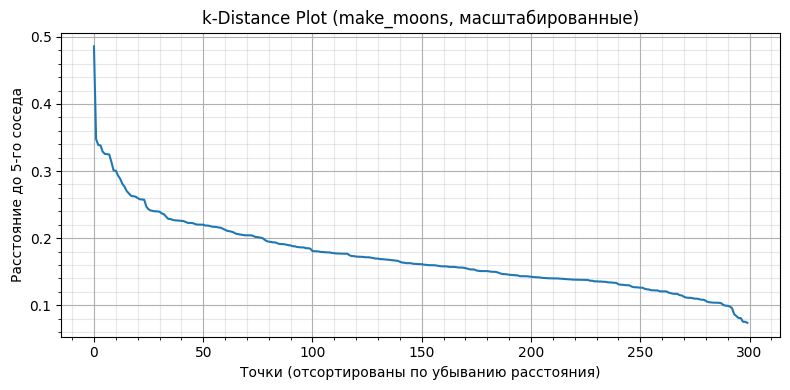

Найдите 'локоть' на графике и запишите подходящее значение eps:


In [4]:
# Масштабируем данные
scaler_moons = StandardScaler()
X_moons_scaled = scaler_moons.fit_transform(X_moons)

k = 5

# YOUR CODE HERE
# 1. Создайте NearestNeighbors(n_neighbors=k) и обучите на X_moons_scaled
# 2. Вызовите .kneighbors() для получения матрицы расстояний
# 3. Возьмите расстояние до k-го соседа (последний столбец distances)
# 4. Отсортируйте по убыванию

model_nearest_neighbors = NearestNeighbors(n_neighbors=k)
model_nearest_neighbors.fit(X_moons_scaled)
distances, indices = model_nearest_neighbors.kneighbors()
k_distances_moons = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_distances_moons)
plt.xlabel("Точки (отсортированы по убыванию расстояния)")
plt.ylabel(f"Расстояние до {k}-го соседа")
plt.title("k-Distance Plot (make_moons, масштабированные)")
plt.grid(True)                 # основная сетка
plt.minorticks_on()            # включаем мелкие деления
plt.grid(which='minor', alpha=0.3)
plt.tight_layout()
plt.show()

print("Найдите 'локоть' на графике и запишите подходящее значение eps:")

**❓ Вопрос для размышления:** Где находится «локоть»? Как он указывает на границу между точками кластеров и шумом?

- Локоть находится в районе eps = 0.22 - 0.23. После этого начинают расстояния до 5 расстояния расти быстрее, структуры начинают быть не плотными, вокруг этих точек  уже надо расширять больше радиус. Значит область вокруг этих точек начинает быть резко не таким плотным, как для основной массы точек. Это либо шумные точки, либо граница кластера

Аналогично сделаем для circles. Тут eps = 0.29

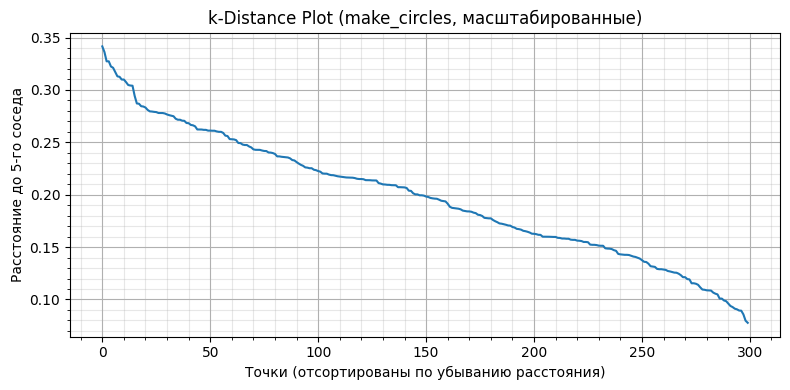

Найдите 'локоть' на графике и запишите подходящее значение eps: 0.29


In [5]:
# Масштабируем make_circles
scaler_circles = StandardScaler()
X_circles_scaled = scaler_circles.fit_transform(X_circles)

model_nearest_neighbors = NearestNeighbors(n_neighbors=k)
model_nearest_neighbors.fit(X_circles_scaled)
distances, indices = model_nearest_neighbors.kneighbors()
k_distances_circles = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_distances_circles)
plt.xlabel("Точки (отсортированы по убыванию расстояния)")
plt.ylabel(f"Расстояние до {k}-го соседа")
plt.title("k-Distance Plot (make_circles, масштабированные)")
plt.grid(True)                 # основная сетка
plt.minorticks_on()            # включаем мелкие деления
plt.grid(which='minor', alpha=0.3)
plt.tight_layout()
plt.show()

print("Найдите 'локоть' на графике и запишите подходящее значение eps: 0.29")

---
## Шаг 4. DBSCAN на нелинейных датасетах

Применим DBSCAN к `make_moons` и `make_circles`. Обратите внимание на масштабирование.

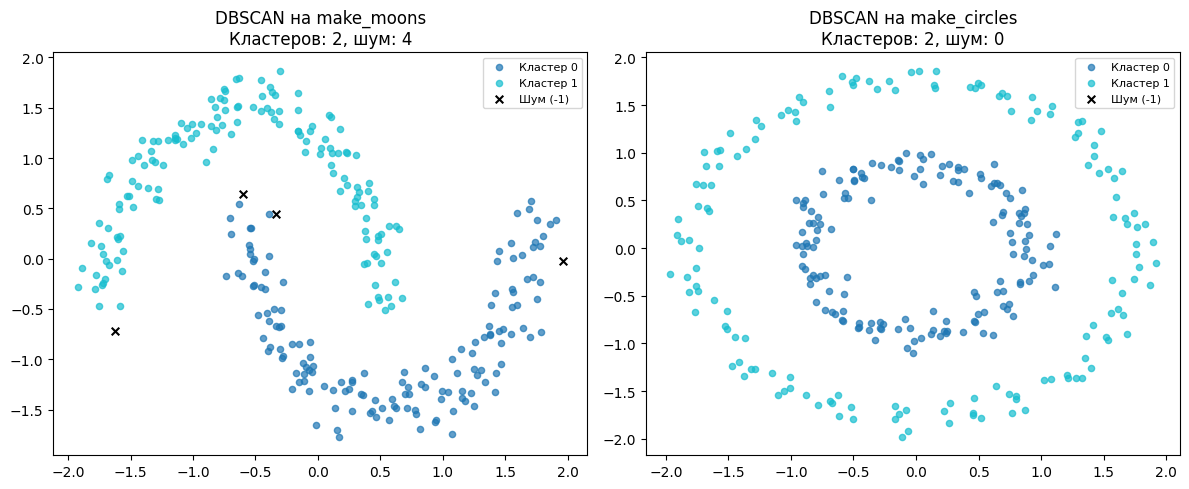

In [6]:
# Масштабируем make_circles
scaler_circles = StandardScaler()
X_circles_scaled = scaler_circles.fit_transform(X_circles)

# YOUR CODE HERE
# 1. Создайте DBSCAN с подобранным eps (из k-distance plot) и min_samples=5
# 2. Примените fit_predict к X_moons_scaled и X_circles_scaled
# 3. Подберите параметры так, чтобы алгоритм нашёл 2 кластера


db_moons = DBSCAN(eps=0.24, min_samples=5)
labels_db_moons = db_moons.fit_predict(X_moons_scaled)

db_circles = DBSCAN(eps=0.305, min_samples=5)
labels_db_circles = db_circles.fit_predict(X_circles_scaled)

# Вспомогательная функция для визуализации
def plot_dbscan_results(X, labels, title, ax):
    """Визуализирует результаты DBSCAN.
    Корневые точки — крупные, граничные — обычные, шум — крестики."""
    noise_mask = labels == -1
    colors = cm.tab10(np.linspace(0, 1, max(labels)+1)) if max(labels) >= 0 else []
    
    for i in range(max(labels)+1):
        mask = labels == i
        ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7,
                   color=colors[i], label=f'Кластер {i}')
    
    ax.scatter(X[noise_mask, 0], X[noise_mask, 1],
               s=30, c='black', marker='x', label='Шум (-1)')
    
    n_cl = max(labels) + 1 if max(labels) >= 0 else 0
    n_noise = noise_mask.sum()
    ax.set_title(f"{title}\nКластеров: {n_cl}, шум: {n_noise}")
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_dbscan_results(X_moons_scaled, labels_db_moons, "DBSCAN на make_moons", axes[0])
plot_dbscan_results(X_circles_scaled, labels_db_circles, "DBSCAN на make_circles", axes[1])
plt.tight_layout()
plt.show()

---
## Шаг 5. Сравнение DBSCAN и K-Means на нелинейных данных

In [7]:
# Сравнение силуэта DBSCAN vs K-Means для make_moons

# YOUR CODE HERE
# 1. Обучите KMeans(n_clusters=2) на X_moons_scaled
# 2. Вычислите silhouette_score для K-Means
# 3. Вычислите silhouette_score для DBSCAN (только для некластерных точек!)
#    Подсказка: исключите точки с labels == -1

kmeans_moons = KMeans(n_clusters=2)
labels_kmeans_moons = kmeans_moons.fit_predict(X_moons_scaled)
kmeans_mask = labels_kmeans_moons != -1

dbscan_mask = labels_db_moons != -1

score_kmeans = silhouette_score(
    X_moons_scaled[kmeans_mask],
    labels_kmeans_moons[kmeans_mask]
)
score_dbscan = silhouette_score(
    X_moons_scaled[dbscan_mask],
    labels_db_moons[dbscan_mask]
)

print("=== Коэффициент силуэта на make_moons ===")
print(f"K-Means (K=2): {score_kmeans:.3f}" if score_kmeans is not None else "K-Means: не вычислен")
print(f"DBSCAN:        {score_dbscan:.3f}" if score_dbscan is not None else "DBSCAN: не вычислен")

=== Коэффициент силуэта на make_moons ===
K-Means (K=2): 0.494
DBSCAN:        0.391


**❓ Вопрос для размышления:** Какой алгоритм получил лучший силуэт? Соответствует ли это визуальному впечатлению? Можно ли всегда доверять силуэту как абсолютной мере качества?

- Несмотря на то, что DBSCAN лучше разделил, тем не менее, лучший коэффициент получил KMeans. Все дело в самой метрике, идея которой состоит в том, чтобы расстояние до точек своего кластера в основном было меньше, чем до точек других кластеров. Любит компактные и выпуклы кластеры. Однако наши точки могут иметь далекие расстояния, но принадлежать одной луне (на разных сторонах луны). Поэтому силуэту не стоит доверять все цело, если у нас нету знания, что кластеры являются выпуклыми и компактными на самом деле

---
## Шаг 6. Исследование влияния гиперпараметров

Посмотрим, как меняется результат DBSCAN при разных значениях `eps` и `min_samples`.

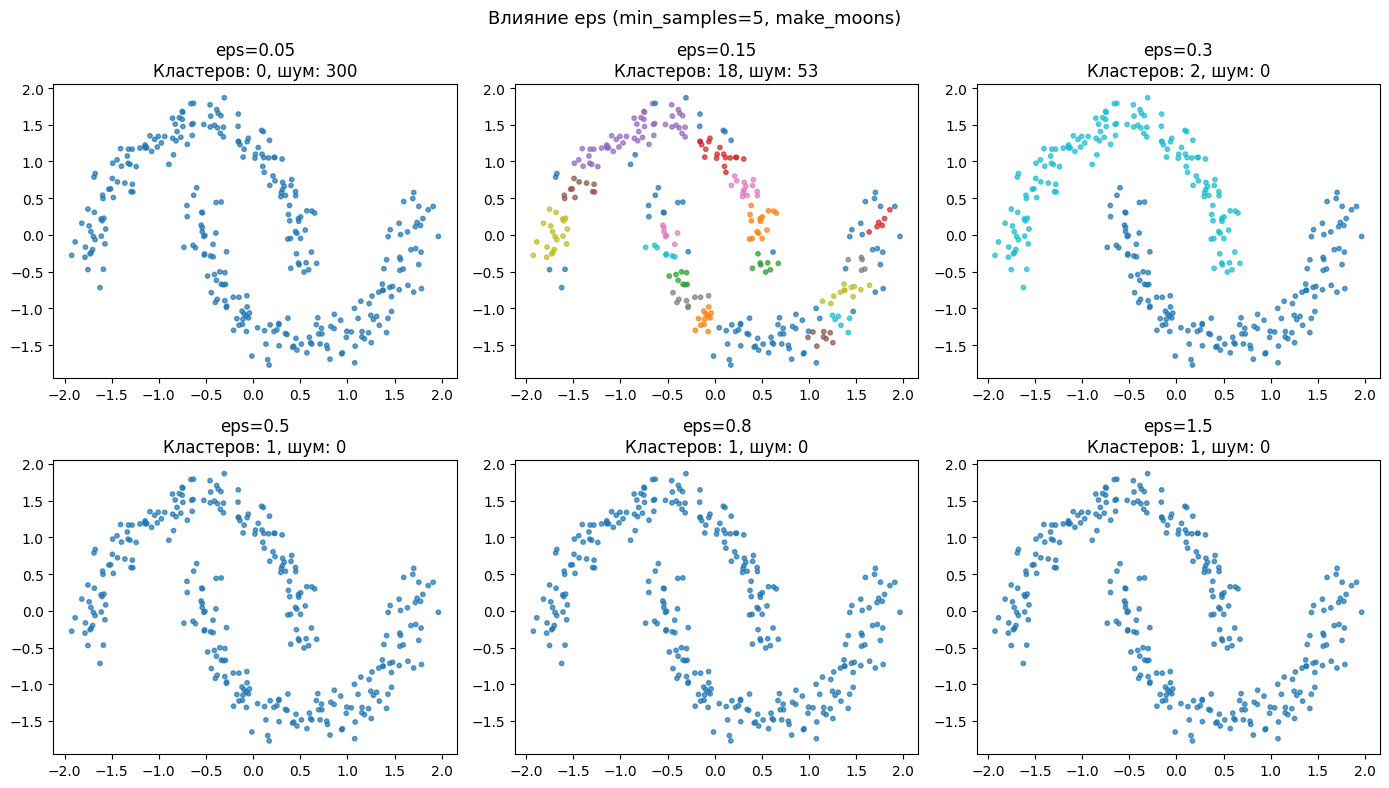

In [8]:
# Сетка eps при фиксированном min_samples=5
eps_values = [0.05, 0.15, 0.3, 0.5, 0.8, 1.5]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, eps_val in enumerate(eps_values):
    # YOUR CODE HERE
    # 1. Запустите DBSCAN(eps=eps_val, min_samples=5) на X_moons_scaled
    # 2. Получите метки
    # 3. Посчитайте число кластеров и шумовых точек
    # 4. Отобразите scatter plot с цветами по меткам
    #    Шумовые точки (label == -1) рисуйте чёрными крестиками

    dbscan_eps = DBSCAN(eps=eps_val, min_samples=5)
    labels_i = dbscan_eps.fit_predict(X_moons_scaled)
    
    if labels_i is not None:
        n_cl = len(set(labels_i)) - (1 if -1 in labels_i else 0)
        n_noise = (labels_i == -1).sum()
        axes[i].scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1],
                        c=labels_i, cmap='tab10', s=10, alpha=0.7)
        axes[i].set_title(f"eps={eps_val}\nКластеров: {n_cl}, шум: {n_noise}")
    else:
        axes[i].set_title(f"eps={eps_val} (не вычислено)")

plt.suptitle("Влияние eps (min_samples=5, make_moons)", fontsize=13)
plt.tight_layout()
plt.show()

**❓ Вопрос для размышления:** При каком `eps` алгоритм нашёл два правильных кластера? Что происходит при слишком малом и слишком большом значении?

- Найдено при eps = 0.3
- При слишком маленьком eps может быть выделения многих объектов как шум (0 кластеров). 
- При промежуточных eps идет большое количество кластеров. 
- При слишком большом eps идет уменьшение кластеров (соседние кластеры сливаются). Однако 0 кластеров не может быть, шум в основном уменьшается. 

---
## Шаг 7. DBSCAN на реальном датасете Wine

Теперь перейдём к реальным данным. Датасет Wine: 178 образцов вина из трёх сортов винограда, 13 химических признаков.

In [9]:
# Загрузка датасета Wine
wine = load_wine()
X_wine = wine.data
y_wine = wine.target  # истинные метки (не используем при кластеризации!)
feature_names = wine.feature_names

print(f"Форма данных: {X_wine.shape}")
print(f"Признаки: {feature_names}")
print(f"\nСтатистика признаков:")
df_wine = pd.DataFrame(X_wine, columns=feature_names)
print(df_wine.describe().round(2))

Форма данных: (178, 13)
Признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Статистика признаков:
       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count   178.00      178.00  178.00             178.00     178.00   
mean     13.00        2.34    2.37              19.49      99.74   
std       0.81        1.12    0.27               3.34      14.28   
min      11.03        0.74    1.36              10.60      70.00   
25%      12.36        1.60    2.21              17.20      88.00   
50%      13.05        1.87    2.36              19.50      98.00   
75%      13.68        3.08    2.56              21.50     107.00   
max      14.83        5.80    3.23              30.00     162.00   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count         178.00      178.00             

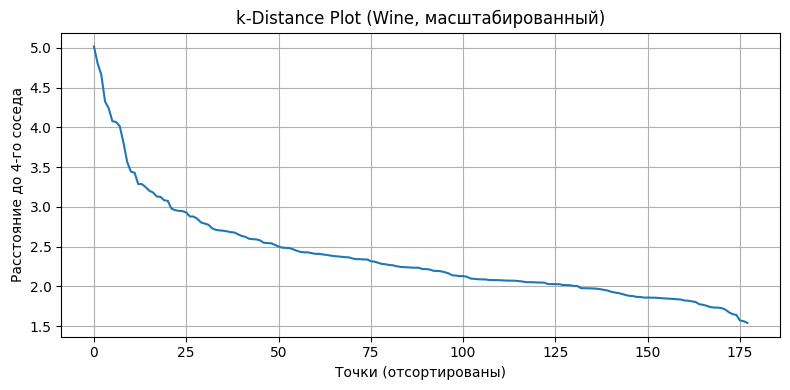

In [10]:
# YOUR CODE HERE
# 1. Масштабируйте X_wine с помощью StandardScaler
# 2. Постройте k-distance plot (k=4)
# 3. Визуально определите «локоть» и запишите подходящее eps

scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)  # замените
k_wine = 4
neighbor_wine = NearestNeighbors(n_neighbors=k_wine)
neighbor_wine.fit(X_wine_scaled)
wine_dictances, wine_indices = neighbor_wine.kneighbors()
k_dist_wine = np.sort(wine_dictances[:, -1])[::-1]

plt.figure(figsize=(8, 4))
if k_dist_wine is not None:
    plt.plot(k_dist_wine)
plt.xlabel("Точки (отсортированы)")
plt.ylabel(f"Расстояние до {k_wine}-го соседа")
plt.title("k-Distance Plot (Wine, масштабированный)")
plt.grid(True)
plt.tight_layout()
plt.show()

Локоть находится где-то в районе eps = 2.5 - 3.0. Но ниже мне пришлось снизить, чтобы было именно 3 кластера.

In [35]:
# YOUR CODE HERE
# 1. Запустите DBSCAN на X_wine_scaled с выбранным eps и min_samples=4
# 2. Выведите: число кластеров, число шумовых точек, долю шума
# 3. Если кластеров > 1, вычислите силуэт (исключив шум)

eps_wine = 2.15  # ИЗМЕНИТЕ на основе k-distance plot
wine_dbscan = DBSCAN(eps=eps_wine, min_samples=4)
dbscan_labels_wine = wine_dbscan.fit_predict(X_wine_scaled)

print("=== Результаты DBSCAN на Wine ===")
# ваш код для вывода статистики
n_clusters_wine = len(set(dbscan_labels_wine)) - (1 if -1 in dbscan_labels_wine else 0)
n_noise = np.sum(dbscan_labels_wine == -1)
percent_noise = n_noise * 100 / len(dbscan_labels_wine)
print(f'Кластеров - {n_clusters_wine}')
print(f'Шумовых точек - {n_noise} ({percent_noise:.2f}% процентов)')

=== Результаты DBSCAN на Wine ===
Кластеров - 3
Шумовых точек - 55 (30.90% процентов)


---
## Шаг 8. Анализ шумовых точек

Шумовые точки — это объекты, которые DBSCAN не смог отнести ни к одному кластеру. В задаче кластеризации они могут нести важную информацию.

In [37]:
# YOUR CODE HERE
# 1. Выберите строки X_wine, соответствующие шумовым точкам (labels_wine == -1)
# 2. Создайте DataFrame с признаками шумовых точек
# 3. Сравните среднее значение признаков шумовых точек
#    со средним по всей выборке (df_wine.mean())
# 4. Какие признаки у шумовых точек сильно отличаются от среднего?

noise_mask_wine = dbscan_labels_wine == -1   # маска для шумовых точек
X_wine_noise =  X_wine[noise_mask_wine]     # признаки шумовых точек

print("=== Средние значения признаков ===")
df_noise_info = pd.DataFrame({
    'Признаки': feature_names,
    'Среднее по шумовым': X_wine_noise.mean(axis=0),
    'Среднее по всем': X_wine.mean(axis=0)
})
print(df_noise_info)

=== Средние значения признаков ===
                        Признаки  Среднее по шумовым  Среднее по всем
0                        alcohol           12.727636        13.000618
1                     malic_acid            2.501273         2.336348
2                            ash            2.352545         2.366517
3              alcalinity_of_ash           20.029091        19.494944
4                      magnesium          101.454545        99.741573
5                  total_phenols            2.352182         2.295112
6                     flavanoids            2.047455         2.029270
7           nonflavanoid_phenols            0.369091         0.361854
8                proanthocyanins            1.717636         1.590899
9                color_intensity            4.418727         5.058090
10                           hue            0.981745         0.957449
11  od280/od315_of_diluted_wines            2.547818         2.611685
12                       proline          648.381818   

**❓ Вопрос для размышления:** Чем отличаются шумовые точки от остальных? Являются ли они «плохими» данными или это реальные аномалии?

Шумовые точки различаются следующим набором признаком (самые заметные): alcanity_of_ash (чуть выше среднего), magnesium(уже болеее выше среднего), proanthocyanins(выше среднего), color_intensity (ниже среднего), proline(заметно меньше среднего). Это может быть просто необычными образцами вина.

---
## Шаг 9. Итоговое сравнение: DBSCAN vs K-Means на Wine

DBSCAN на 3 кластерах silhouette: 0.20879060403120395
KMeans на 3 кластерах silhouette: 0.2848589191898987


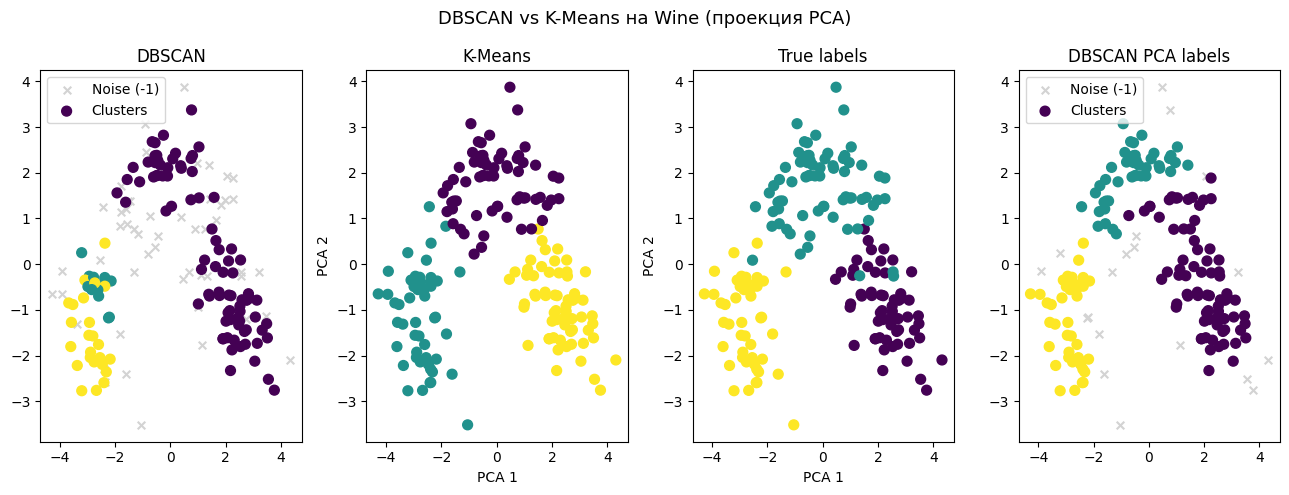

In [41]:
# YOUR CODE HERE
# 1. Обучите KMeans с числом кластеров = числу кластеров DBSCAN
#    (или с n_clusters=3, так как истинных классов 3)
# 2. Вычислите силуэт для K-Means
# 3. Сравните силуэт DBSCAN и K-Means
# 4. Визуализируйте результаты обоих методов в 2D (первые два признака
#    после масштабирования или используйте PCA до 2 компонент)

# Подсказка для PCA:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_wine_2d = pca.fit_transform(X_wine_scaled)

# DBSCAN
# ваш код
mask_non_noise = dbscan_labels_wine != -1
dbscan_silhouette = silhouette_score(
    X_wine_scaled[mask_non_noise],
    dbscan_labels_wine[mask_non_noise]
)
print(f'DBSCAN на 3 кластерах silhouette: {dbscan_silhouette}')


# K-Means
# ваш код
kmeans_wine = KMeans(
    n_clusters=3,
    random_state=RANDOM_STATE,
    n_init=10
)
kmeans_wine_labels = kmeans_wine.fit_predict(X_wine_scaled)
kmeans_silhouette = silhouette_score(
    X_wine_scaled,
    kmeans_wine_labels
)
print(f'KMeans на 3 кластерах silhouette: {kmeans_silhouette}')


fig, axes = plt.subplots(1, 4, figsize=(13, 5))

#DBSCAN
noise_mask = dbscan_labels_wine == -1
cluster_mask = dbscan_labels_wine != -1
# шум
axes[0].scatter(
    X_wine_2d[noise_mask, 0],
    X_wine_2d[noise_mask, 1],
    c='lightgray',
    s=30,
    marker='x',
    label='Noise (-1)'
)
# кластеры
axes[0].scatter(
    X_wine_2d[cluster_mask, 0],
    X_wine_2d[cluster_mask, 1],
    c=dbscan_labels_wine[cluster_mask],
    cmap='viridis',
    s=50,
    label='Clusters'
)

axes[0].set_title("DBSCAN")
axes[0].legend()

#KMeans
scatter2 = axes[1].scatter(
    X_wine_2d[:, 0],
    X_wine_2d[:, 1],
    c=kmeans_wine_labels,
    cmap='viridis',
    s=50
)
axes[1].set_title("K-Means")
axes[1].set_xlabel("PCA 1")
axes[1].set_ylabel("PCA 2")

#True Labels
scatter3 = axes[2].scatter(
    X_wine_2d[:, 0],
    X_wine_2d[:, 1],
    c=y_wine,
    cmap='viridis',
    s=50
)
axes[2].set_title("True labels")
axes[2].set_xlabel("PCA 1")
axes[2].set_ylabel("PCA 2")

#DBSCAN на PCA
wine_dbscan = DBSCAN(eps=0.3, min_samples=4)
X_wine_2d_scaled = StandardScaler().fit_transform(X_wine_2d)
dbscan_labels_wine_pca = wine_dbscan.fit_predict(X_wine_2d_scaled)
labels_pca = dbscan_labels_wine_pca
noise_mask = labels_pca == -1
cluster_mask = labels_pca != -1
axes[3].scatter(
    X_wine_2d[noise_mask, 0],
    X_wine_2d[noise_mask, 1],
    c='lightgray',
    s=30,
    marker='x',
    label='Noise (-1)'
)
axes[3].scatter(
    X_wine_2d[cluster_mask, 0],
    X_wine_2d[cluster_mask, 1],
    c=labels_pca[cluster_mask],
    cmap='viridis',
    s=50,
    label='Clusters'
)
axes[3].set_title("DBSCAN PCA labels")
axes[3].legend()

plt.suptitle("DBSCAN vs K-Means на Wine (проекция PCA)", fontsize=13)
plt.tight_layout()
plt.show()

Можно заметить, что все-таки лучше всего справился с задачей kmeans. Можно заметить, что реальные классы имеют разную плотность и из-за этого dbscan не смог увидеть эти кластеры. Плюс шума многовато. DBSCAN сделал кластеры даже более вогнутые. Можно заметить, что dbscan в PCA пространстве хоть немного помог (так как есть в больших размерностях существует некое проклятие, что близкие точки могут иметь уже не такое маленькое расстояние). Лучше всех справился K-means, с его подходом с центроидами.

---
## Шаг 10. Итоговые выводы

Ответьте на следующие вопросы в ячейке ниже (текст Markdown):

**1. Когда DBSCAN выигрывает у K-Means?**

> Когда кластеры имеют вогнутую форму (например луны) и/или имеют предполжительно один и тот же центр (концетрированные окружности).

**2. Когда K-Means предпочтительнее?**

> Когда кластеры имеют разную плотность. И когда есть основание предполагать, что кластеры имеют выпуклую форму.

**3. Почему масштабирование обязательно для DBSCAN?**

> Мы работаем с расстоянием. Проекции расстояний на любые признаки должно быть соразмерно, иначе один признак будет перекрывать другой.

**4. Как интерпретировать шумовые точки в датасете Wine?**

> Как редкие сорта вин возможно, которые выделяются необычным составом

**5. Можно ли корректно сравнивать силуэт DBSCAN и K-Means напрямую? Почему?**

> Нет. Идея dbscan работать с плотностями. Поэтому идея силуэта того, что среднее расстояние до точек его кластера должно быть меньше, чем других кластеров, возможно провалиться. Примером являются луны, где крайней точке хоть близко до крайней точки чужой луны, чем до противоположной крайней точки своей же луны. Плюс хочется отметить момент. У нас сравнение идет нечестным. ведь в DBSCAN есть шумовые точки, которые из сравнения удаляются, в отличие от KMeans, где таковых нет вовсе.